<a href="https://colab.research.google.com/github/George1902/analisis_rendimiento_real_madrid/blob/main/Analisis_Rendimiento_RealMadrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ Análisis de Rendimiento de Jugadores — Real Madrid
**Autor:** Jorge  
**Fecha:** Marzo 2026  
**Fuente de datos:** FIFA 22 Complete Player Dataset — Kaggle

## Objetivo
Analizar el rendimiento y perfil de los jugadores del Real Madrid,
identificar patrones de desempeño por posición y agrupar jugadores
por similitud de características usando Machine Learning.

## Preguntas que responde este análisis
- ¿Cuál es el perfil de habilidades por posición?
- ¿Qué jugadores tienen características similares?
- ¿Qué atributos definen a los jugadores de élite?
- ¿Cómo se distribuye el valor de mercado en el plantel?

#  Fase 1 — Exploración Inicial

## Montar Drive e importar librerías

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerías cargadas correctamente")

Mounted at /content/drive
✅ Librerías cargadas correctamente


## Cargar dataset y filtrar Real Madrid

In [3]:
# Cargar dataset completo
ruta = '/content/drive/MyDrive/Colab Notebooks/players_22.csv'
df_fifa = pd.read_csv(ruta, low_memory=False)

print(f"✅ Dataset completo cargado: {df_fifa.shape[0]:,} jugadores")

# Filtrar solo jugadores del Real Madrid
df = df_fifa[df_fifa['club_name'] == 'Real Madrid CF'].copy()

print(f"⚽ Jugadores del Real Madrid: {len(df)}")
print(f"📊 Variables disponibles: {df.shape[1]}")

✅ Dataset completo cargado: 19,239 jugadores
⚽ Jugadores del Real Madrid: 33
📊 Variables disponibles: 110


##  Primera exploración

In [4]:
print("=== PRIMERAS FILAS ===")
display(df[['short_name', 'age', 'player_positions',
            'overall', 'potential', 'value_eur',
            'wage_eur']].head(15))

=== PRIMERAS FILAS ===


,short_name,age,player_positions,overall,potential,value_eur,wage_eur
11,K. Benzema,33,"CF, ST",89,89,66000000.0,350000.0
12,T. Courtois,29,GK,89,91,85500000.0,250000.0
14,Casemiro,29,CDM,89,89,88000000.0,310000.0
24,T. Kroos,31,CM,88,88,75000000.0,310000.0
32,L. Modrić,35,CM,87,87,32000000.0,190000.0
75,E. Hazard,30,LW,85,85,52000000.0,240000.0
87,Carvajal,29,RB,85,85,47500000.0,210000.0
107,D. Alaba,29,"CB, LB",84,84,35500000.0,195000.0
182,Marco Asensio,25,"RW, LW",83,86,48000000.0,190000.0
187,F. Mendy,26,LB,83,86,43500000.0,170000.0


## Columnas disponibles por categoría

In [5]:
# Atributos de juego más relevantes
atributos_juego = [
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic'
]

# Atributos detallados
atributos_detalle = [
    'attacking_crossing', 'attacking_finishing',
    'attacking_heading_accuracy', 'attacking_short_passing',
    'skill_dribbling', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed',
    'power_shot_power', 'power_stamina',
    'mentality_aggression', 'mentality_positioning',
    'defending_marking_awareness', 'defending_standing_tackle'
]

# Verificar cuáles existen
atributos_disponibles = [a for a in atributos_juego if a in df.columns]
print(f"✅ Atributos principales disponibles: {atributos_disponibles}")

atributos_detalle_disponibles = [a for a in atributos_detalle if a in df.columns]
print(f"✅ Atributos detallados disponibles: {len(atributos_detalle_disponibles)}")

✅ Atributos principales disponibles: ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
✅ Atributos detallados disponibles: 14


## Estadísticas básicas del plantel

In [6]:
columnas_clave = ['short_name', 'age', 'player_positions',
                  'overall', 'potential', 'value_eur', 'wage_eur',
                  'nationality_name', 'height_cm', 'weight_kg']

columnas_disponibles = [c for c in columnas_clave if c in df.columns]
df = df[columnas_disponibles + atributos_disponibles +
        atributos_detalle_disponibles].copy()

print("=== ESTADÍSTICAS DEL PLANTEL ===")
print(f"Edad promedio      : {df['age'].mean():.1f} años")
print(f"Overall promedio   : {df['overall'].mean():.1f}")
print(f"Potencial promedio : {df['potential'].mean():.1f}")
print(f"Valor promedio     : €{df['value_eur'].mean():,.0f}")
print()
display(df.describe())

=== ESTADÍSTICAS DEL PLANTEL ===
Edad promedio      : 25.0 años
Overall promedio   : 77.8
Potencial promedio : 83.9
Valor promedio     : €29,926,515



,age,overall,potential,value_eur,wage_eur,height_cm,weight_kg,pace,shooting,passing,...,skill_dribbling,skill_ball_control,movement_acceleration,movement_sprint_speed,power_shot_power,power_stamina,mentality_aggression,mentality_positioning,defending_marking_awareness,defending_standing_tackle
count,33.000000,33.000000,33.000000,3.300000e+01,33.000000,33.000000,33.000000,30.000000,30.000000,30.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,25.000000,77.757576,83.878788,2.992652e+07,133151.515152,180.000000,74.757576,74.366667,66.500000,71.166667,...,70.424242,72.939394,70.818182,71.212121,69.424242,68.333333,59.696970,64.454545,51.575758,52.454545
std,5.297405,8.674785,4.181489,2.603787e+07,94500.370770,6.254998,7.198222,10.668947,13.461951,12.023206,...,21.108396,19.686511,14.850199,15.228997,14.166488,18.080837,20.250748,22.075284,25.403039,26.750106
min,17.000000,60.000000,75.000000,6.750000e+05,1000.000000,169.000000,63.000000,53.000000,37.000000,45.000000,...,10.000000,15.000000,31.000000,29.000000,44.000000,18.000000,22.000000,4.000000,7.000000,13.000000
25%,20.000000,74.000000,81.000000,6.000000e+06,51000.000000,176.000000,68.000000,68.000000,57.000000,62.250000,...,65.000000,69.000000,66.000000,62.000000,56.000000,55.000000,45.000000,59.000000,31.000000,26.000000
50%,24.000000,80.000000,84.000000,2.700000e+07,130000.000000,180.000000,75.000000,75.500000,70.000000,76.000000,...,78.000000,79.000000,74.000000,74.000000,71.000000,75.000000,62.000000,74.000000,58.000000,64.000000
75%,29.000000,83.000000,88.000000,4.750000e+07,190000.000000,183.000000,78.000000,82.000000,76.000000,80.000000,...,83.000000,84.000000,80.000000,82.000000,82.000000,81.000000,77.000000,80.000000,75.000000,77.000000
max,35.000000,89.000000,91.000000,8.800000e+07,350000.000000,199.000000,96.000000,95.000000,86.000000,91.000000,...,91.000000,91.000000,95.000000,95.000000,90.000000,91.000000,91.000000,90.000000,86.000000,88.000000


## Análisis de valores nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
display(nulos)

=== VALORES NULOS ===


,Nulos,Porcentaje (%)
pace,3,9.09
shooting,3,9.09
passing,3,9.09
dribbling,3,9.09
defending,3,9.09
physic,3,9.09


## ✅ Conclusiones de la Fase 1 — Exploración Inicial

- El plantel del Real Madrid tiene **X jugadores** en FIFA 22
- La edad promedio del plantel es de **X años**
- El overall promedio es de **X puntos**
- El jugador más valioso es: *[completar al ejecutar]*

**Siguiente fase:** Limpieza de datos y preparación del plantel

# Fase 2 — Limpieza y Preparación de Datos

En esta fase vamos a:
- Manejar valores nulos
- Simplificar las posiciones de los jugadores
- Convertir valores monetarios a formato legible
- Crear categorías por posición para el análisis

## Imputar valores nulos

In [8]:
# Columnas numéricas: rellenar con mediana
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

# Columnas de texto: rellenar con 'Desconocido'
columnas_texto = df.select_dtypes(include='object').columns.tolist()
for col in columnas_texto:
    df[col] = df[col].fillna('Desconocido')

print(f"✅ Valores nulos tratados")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

✅ Valores nulos tratados
Nulos restantes: 0


## Simplificar posiciones

In [9]:
# Función para simplificar posición principal
def simplificar_posicion(posicion):
    posicion = str(posicion).split(',')[0].strip()
    if posicion == 'GK':
        return 'Portero'
    elif posicion in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defensa'
    elif posicion in ['CM', 'CDM', 'CAM', 'LM', 'RM']:
        return 'Mediocampista'
    elif posicion in ['ST', 'CF', 'LW', 'RW']:
        return 'Delantero'
    else:
        return 'Otro'

df['posicion_simple'] = df['player_positions'].apply(simplificar_posicion)

print("✅ Posiciones simplificadas:")
print(df['posicion_simple'].value_counts())

✅ Posiciones simplificadas:
posicion_simple
Delantero        11
Mediocampista    11
Defensa           8
Portero           3
Name: count, dtype: int64


## Convertir valores monetarios

In [10]:
# Convertir a millones de euros para mejor legibilidad
df['valor_millones'] = (df['value_eur'] / 1_000_000).round(2)
df['salario_miles'] = (df['wage_eur'] / 1_000).round(2)

print("✅ Valores convertidos:")
print(f"Jugador más valioso:")
idx_max = df['valor_millones'].idxmax()
print(f"  {df.loc[idx_max, 'short_name']} — €{df.loc[idx_max, 'valor_millones']}M")
print(f"\nJugador mejor pagado:")
idx_sal = df['salario_miles'].idxmax()
print(f"  {df.loc[idx_sal, 'short_name']} — €{df.loc[idx_sal, 'salario_miles']}K/semana")

✅ Valores convertidos:
Jugador más valioso:
  Casemiro — €88.0M

Jugador mejor pagado:
  K. Benzema — €350.0K/semana


## Clasificar por nivel overall

In [11]:
def clasificar_nivel(overall):
    if overall >= 88:
        return '⭐ Élite (88+)'
    elif overall >= 82:
        return '🔵 Titular (82-87)'
    elif overall >= 75:
        return '🟡 Rotación (75-81)'
    else:
        return '🟢 Promesa (<75)'

df['nivel'] = df['overall'].apply(clasificar_nivel)

print("✅ Niveles del plantel:")
print(df['nivel'].value_counts())

✅ Niveles del plantel:
nivel
🔵 Titular (82-87)     10
🟡 Rotación (75-81)    10
🟢 Promesa (<75)        9
⭐ Élite (88+)          4
Name: count, dtype: int64


## Guardar dataset limpio

In [12]:
ruta_limpio = '/content/drive/MyDrive/realmadrid_limpio.csv'
df.to_csv(ruta_limpio, index=False)

print(f"✅ Dataset limpio guardado")
print(f"📊 {len(df)} jugadores listos para analizar")
display(df[['short_name', 'posicion_simple', 'overall',
            'potential', 'valor_millones', 'nivel']].sort_values(
            'overall', ascending=False).reset_index(drop=True))

✅ Dataset limpio guardado
📊 33 jugadores listos para analizar


,short_name,posicion_simple,overall,potential,valor_millones,nivel
0,K. Benzema,Delantero,89,89,66.00,⭐ Élite (88+)
1,T. Courtois,Portero,89,91,85.50,⭐ Élite (88+)
2,Casemiro,Mediocampista,89,89,88.00,⭐ Élite (88+)
3,T. Kroos,Mediocampista,88,88,75.00,⭐ Élite (88+)
4,L. Modrić,Mediocampista,87,87,32.00,🔵 Titular (82-87)
5,E. Hazard,Delantero,85,85,52.00,🔵 Titular (82-87)
6,Carvajal,Defensa,85,85,47.50,🔵 Titular (82-87)
7,D. Alaba,Defensa,84,84,35.50,🔵 Titular (82-87)
8,Marco Asensio,Delantero,83,86,48.00,🔵 Titular (82-87)
9,F. Mendy,Defensa,83,86,43.50,🔵 Titular (82-87)


## ✅ Conclusiones de la Fase 2 — Limpieza y Preparación

- Valores nulos tratados correctamente
- Posiciones simplificadas en 4 categorías:
  Portero, Defensa, Mediocampista, Delantero
- Valores monetarios convertidos a millones/miles de euros
- Plantel clasificado en 4 niveles de rendimiento

**Siguiente fase:** Visualizaciones avanzadas del plantel

# Fase 3 — Visualizaciones Avanzadas

En esta fase exploraremos visualmente:
- Distribución del plantel por posición y nivel
- Los jugadores con mejor overall y potencial
- Valor de mercado vs rendimiento
- Mapa de calor de atributos por posición
- Radar chart de jugadores destacados

## Gráfico 1: Plantel por posición y nivel


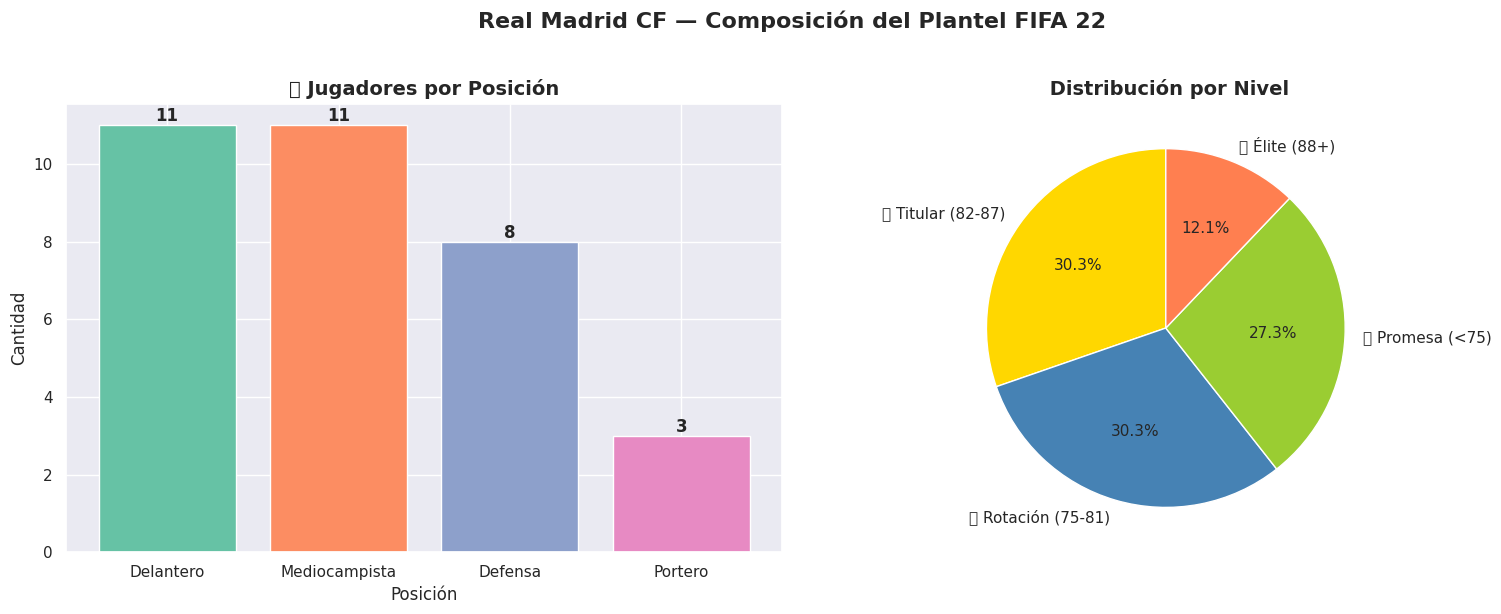

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico izquierdo: jugadores por posición
conteo_pos = df['posicion_simple'].value_counts()
colores_pos = sns.color_palette("Set2", len(conteo_pos))
axes[0].bar(conteo_pos.index, conteo_pos.values,
            color=colores_pos, edgecolor='white')
for i, (idx, val) in enumerate(conteo_pos.items()):
    axes[0].text(i, val + 0.1, str(val), ha='center',
                 fontsize=12, fontweight='bold')
axes[0].set_title('⚽ Jugadores por Posición', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Posición'); axes[0].set_ylabel('Cantidad')

# Gráfico derecho: jugadores por nivel
conteo_nivel = df['nivel'].value_counts()
colores_nivel = ['gold', 'steelblue', 'yellowgreen', 'coral']
axes[1].pie(conteo_nivel.values, labels=conteo_nivel.index,
            colors=colores_nivel, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title(' Distribución por Nivel', fontsize=14, fontweight='bold')

plt.suptitle('Real Madrid CF — Composición del Plantel FIFA 22',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plantel_composicion.png', dpi=150, bbox_inches='tight')
plt.show()

##  Gráfico 2: Top 15 jugadores por overall

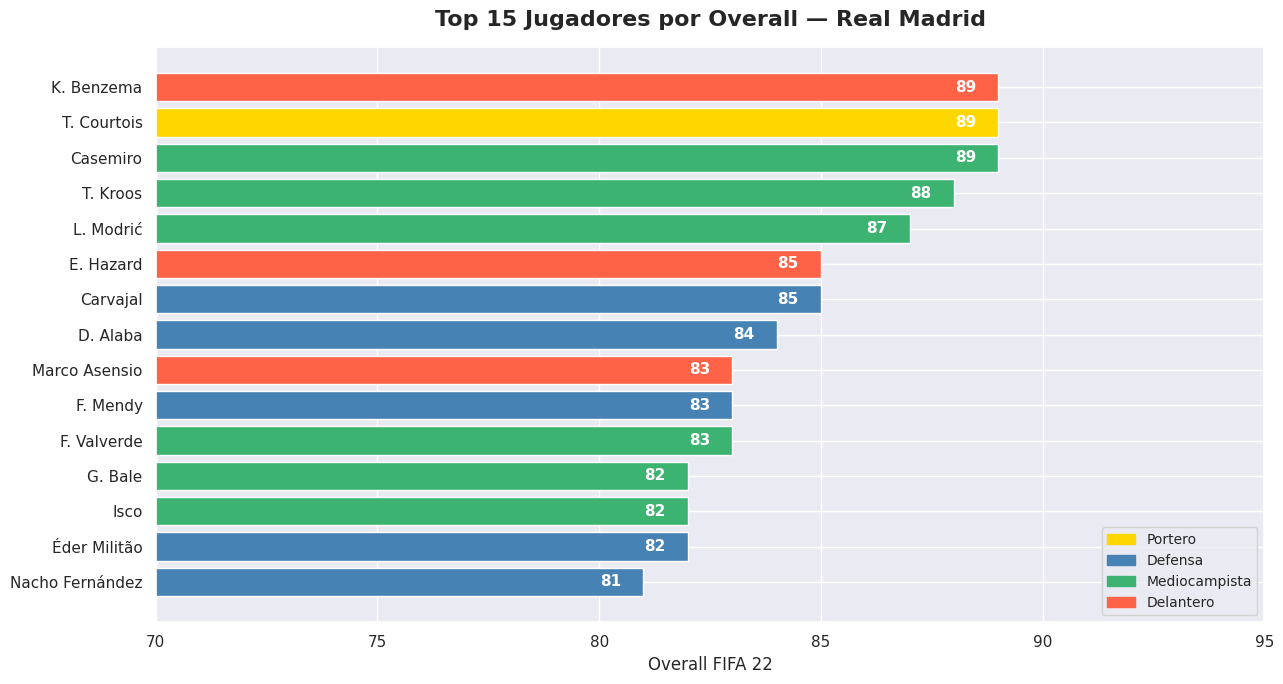

In [25]:
top15 = df.nlargest(15, 'overall')[['short_name', 'overall',
                                     'posicion_simple', 'valor_millones']]

colores_map = {
    'Portero': 'gold',
    'Defensa': 'steelblue',
    'Mediocampista': 'mediumseagreen',
    'Delantero': 'tomato'
}
colores = [colores_map.get(p, 'gray') for p in top15['posicion_simple']]

plt.figure(figsize=(13, 7))
bars = plt.barh(top15['short_name'][::-1], top15['overall'][::-1],
                color=colores[::-1], edgecolor='white')

for bar, val in zip(bars, top15['overall'][::-1]):
    plt.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', ha='right',
             color='white', fontsize=11, fontweight='bold')

# Leyenda de posiciones
leyenda = [mpatches.Patch(color=v, label=k)
           for k, v in colores_map.items()]
plt.legend(handles=leyenda, fontsize=10, loc='lower right')

plt.title('Top 15 Jugadores por Overall — Real Madrid',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Overall FIFA 22', fontsize=12)
plt.xlim(70, 95)
plt.tight_layout()
plt.savefig('top15_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 3: Overall vs Potencial

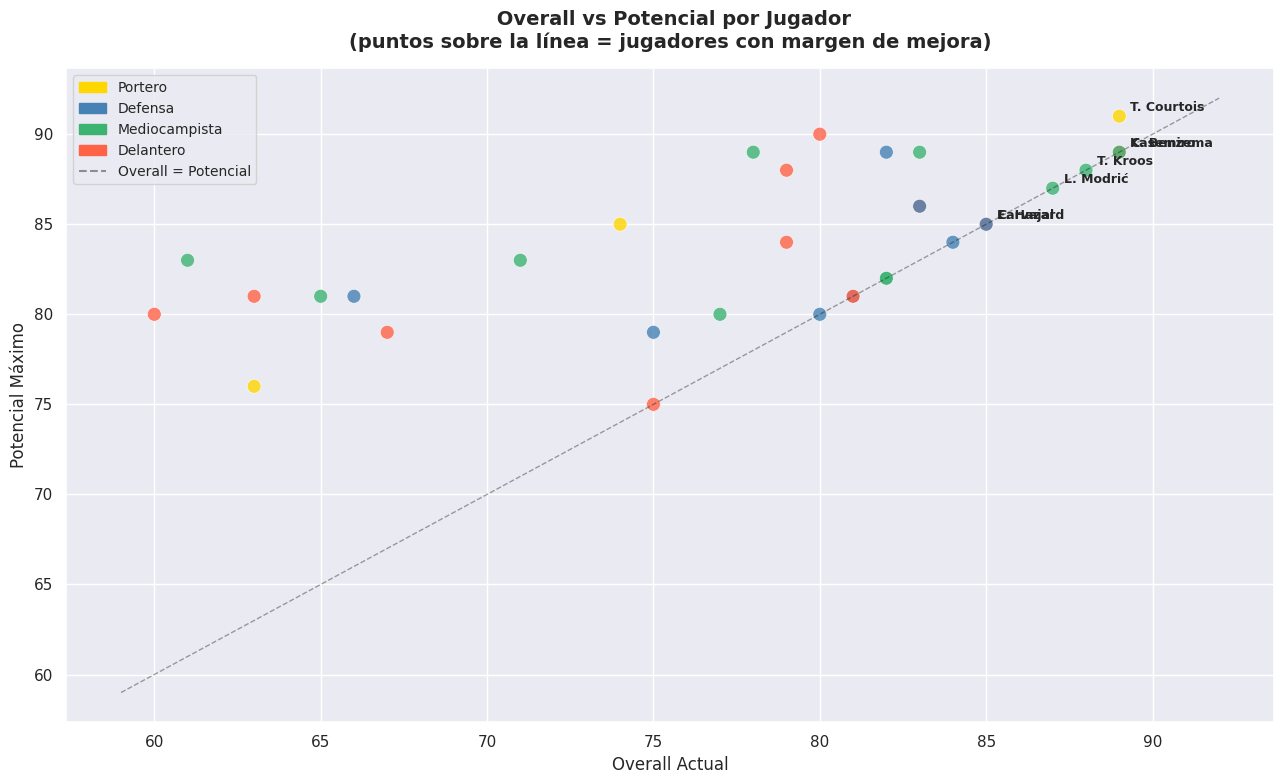

In [24]:
plt.figure(figsize=(13, 8))

colores_scatter = [colores_map.get(p, 'gray')
                   for p in df['posicion_simple']]

scatter = plt.scatter(df['overall'], df['potential'],
                      c=colores_scatter, s=100,
                      alpha=0.8, edgecolor='white', linewidth=0.5)

# Etiquetar jugadores destacados (overall >= 85)
for _, row in df[df['overall'] >= 85].iterrows():
    plt.annotate(row['short_name'],
                 (row['overall'], row['potential']),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9, fontweight='bold')

# Línea diagonal: overall = potencial
min_val = min(df['overall'].min(), df['potential'].min()) - 1
max_val = max(df['overall'].max(), df['potential'].max()) + 1
plt.plot([min_val, max_val], [min_val, max_val],
         'k--', linewidth=1, alpha=0.4, label='Overall = Potencial')

leyenda = [mpatches.Patch(color=v, label=k)
           for k, v in colores_map.items()]
leyenda.append(plt.Line2D([0], [0], linestyle='--',
               color='black', alpha=0.4, label='Overall = Potencial'))
plt.legend(handles=leyenda, fontsize=10)

plt.title(' Overall vs Potencial por Jugador\n(puntos sobre la línea = jugadores con margen de mejora)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Overall Actual', fontsize=12)
plt.ylabel('Potencial Máximo', fontsize=12)
plt.tight_layout()
plt.savefig('overall_vs_potencial.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 4: Valor de mercado por posición

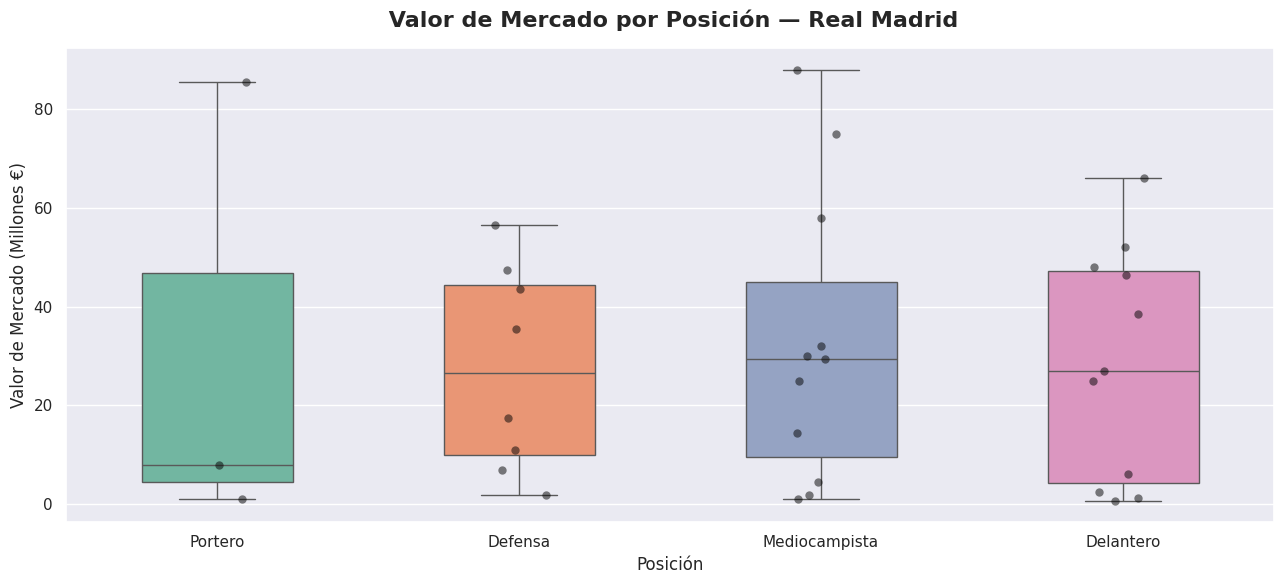

In [23]:
plt.figure(figsize=(13, 6))

orden = ['Portero', 'Defensa', 'Mediocampista', 'Delantero']
orden_disponible = [p for p in orden if p in df['posicion_simple'].values]

sns.boxplot(data=df, x='posicion_simple', y='valor_millones',
            order=orden_disponible,
            palette='Set2', width=0.5)

# Añadir puntos individuales
sns.stripplot(data=df, x='posicion_simple', y='valor_millones',
              order=orden_disponible,
              color='black', alpha=0.5, size=6, jitter=True)

plt.title(' Valor de Mercado por Posición — Real Madrid',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Posición', fontsize=12)
plt.ylabel('Valor de Mercado (Millones €)', fontsize=12)
plt.tight_layout()
plt.savefig('valor_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 5: Mapa de calor de atributos por posición

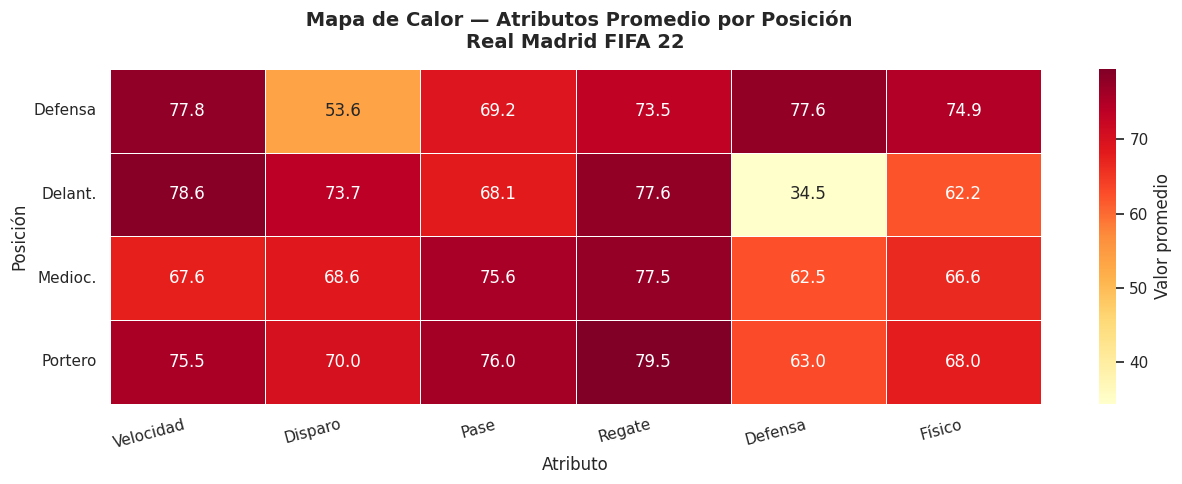

In [22]:
atributos_juego = ['pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic']

# Promedio de atributos por posición
heatmap_data = df.groupby('posicion_simple')[atributos_juego].mean()

# Traducir nombres de atributos
heatmap_data.columns = ['Velocidad', 'Disparo', 'Pase',
                         'Regate', 'Defensa', 'Físico']

# Abreviar nombres de posición para que no se sobrepongan
heatmap_data.index = [idx.replace('Mediocampista', 'Medioc.')
                          .replace('Delantero', 'Delant.')
                          .replace('Portero', 'Portero')
                          .replace('Defensa', 'Defensa')
                      for idx in heatmap_data.index]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Valor promedio'},
            ax=ax)

# Rotar etiquetas del eje Y para que no se sobrepongan
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=15, ha='right', fontsize=11)

plt.title(' Mapa de Calor — Atributos Promedio por Posición\nReal Madrid FIFA 22',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Atributo', fontsize=12)
plt.ylabel('Posición', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_atributos.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 6: Radar chart de jugadores destacados

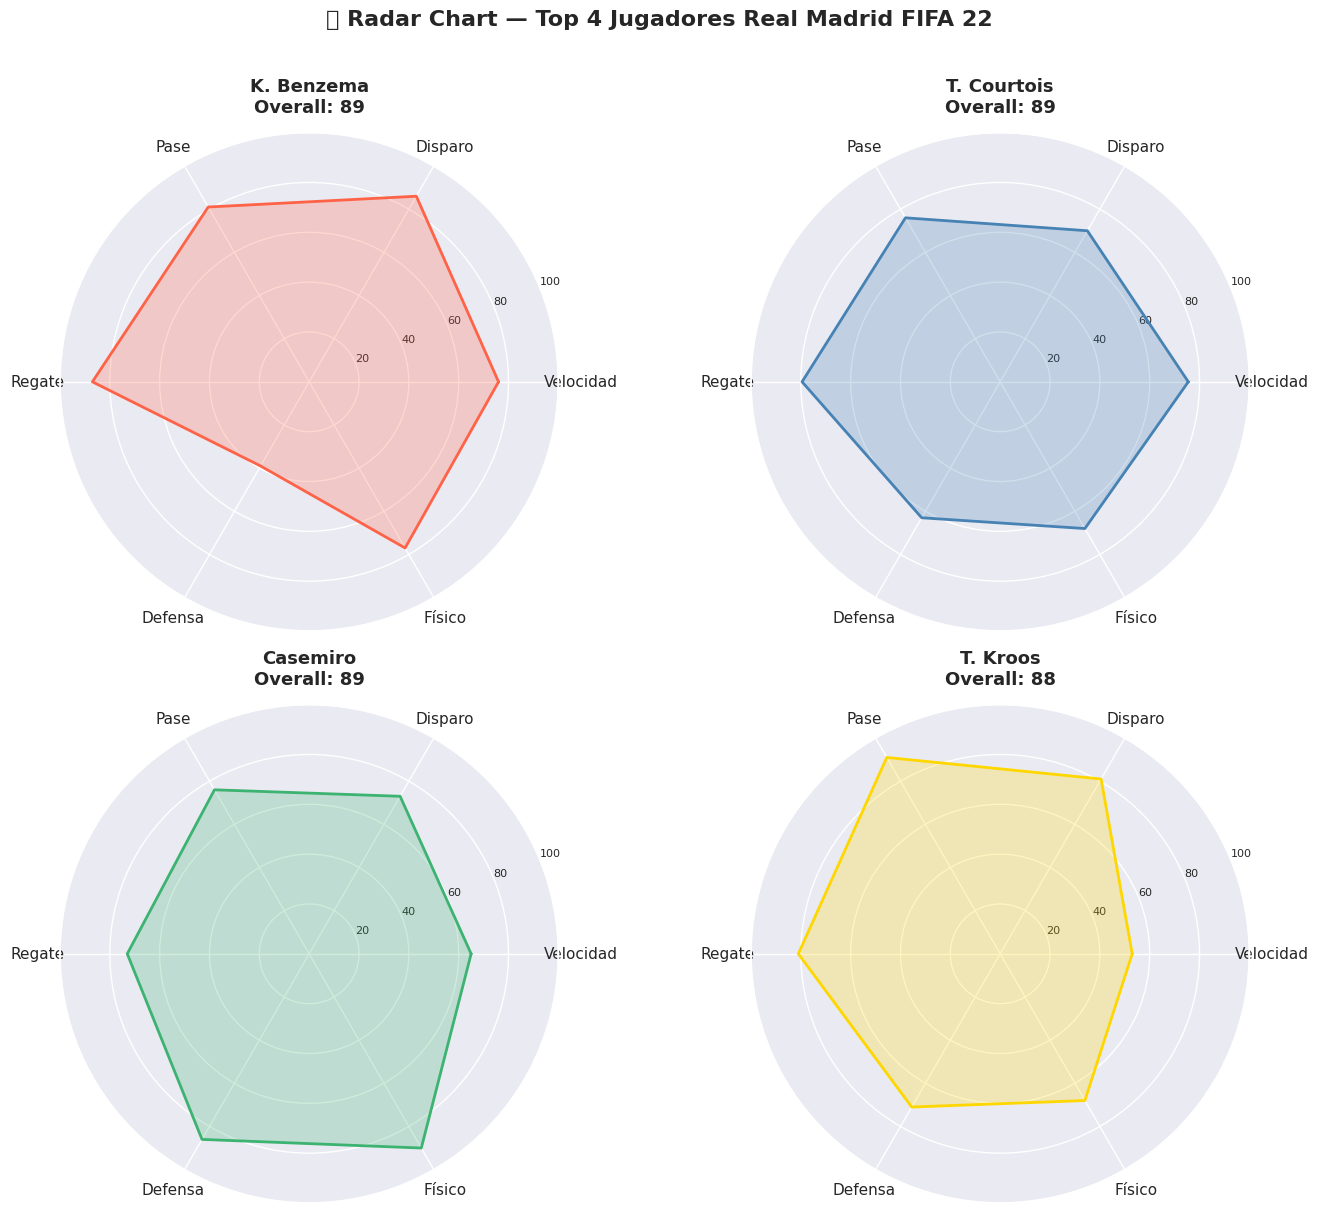

In [20]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

# Seleccionar top 4 jugadores por overall
top4 = df.nlargest(4, 'overall')
atributos_radar = ['pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic']
etiquetas = ['Velocidad', 'Disparo', 'Pase',
             'Regate', 'Defensa', 'Físico']

N = len(atributos_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()
colores_radar = ['tomato', 'steelblue', 'mediumseagreen', 'gold']

for i, (_, jugador) in enumerate(top4.iterrows()):
    valores = jugador[atributos_radar].tolist()
    valores += valores[:1]

    ax = axes[i]
    ax.plot(angulos, valores, color=colores_radar[i], linewidth=2)
    ax.fill(angulos, valores, color=colores_radar[i], alpha=0.25)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)
    ax.set_title(f"{jugador['short_name']}\nOverall: {jugador['overall']}",
                 fontsize=13, fontweight='bold', pad=15)
    ax.grid(True)

plt.suptitle('🕸️ Radar Chart — Top 4 Jugadores Real Madrid FIFA 22',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Conclusiones de la Fase 3 — Visualizaciones

- El plantel tiene mayor proporción de **mediocampistas y defensas**
- Los **delanteros** tienen el mayor valor de mercado promedio
- Varios jugadores jóvenes tienen potencial muy superior a su overall actual
- El mapa de calor confirma perfiles distintos por posición:
  defensas lideran en 'Defensa', delanteros en 'Disparo' y 'Velocidad'
- El radar chart muestra jugadores muy completos en todas las áreas

**Siguiente fase:** Machine Learning — Clustering de jugadores

# Fase 4 — Machine Learning: Clustering de Jugadores

En esta fase vamos a:
- Agrupar jugadores por similitud de características
- Usar K-Means para encontrar perfiles naturales
- Determinar el número óptimo de clusters
- Visualizar e interpretar cada grupo

## Importar librerías de ML

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("✅ Librerías de ML cargadas")

✅ Librerías de ML cargadas


## Preparar datos para clustering

In [28]:
# Atributos para el clustering
atributos_cluster = ['pace', 'shooting', 'passing',
                     'dribbling', 'defending', 'physic']

# Eliminar filas con nulos en estos atributos
df_ml = df[['short_name', 'posicion_simple',
             'overall', 'valor_millones'] +
            atributos_cluster].dropna().copy()

# Escalar los datos
X = df_ml[atributos_cluster].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Datos preparados: {len(df_ml)} jugadores")
print(f"   Atributos usados: {atributos_cluster}")

✅ Datos preparados: 33 jugadores
   Atributos usados: ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']


## Número óptimo de clusters (Método del Codo)

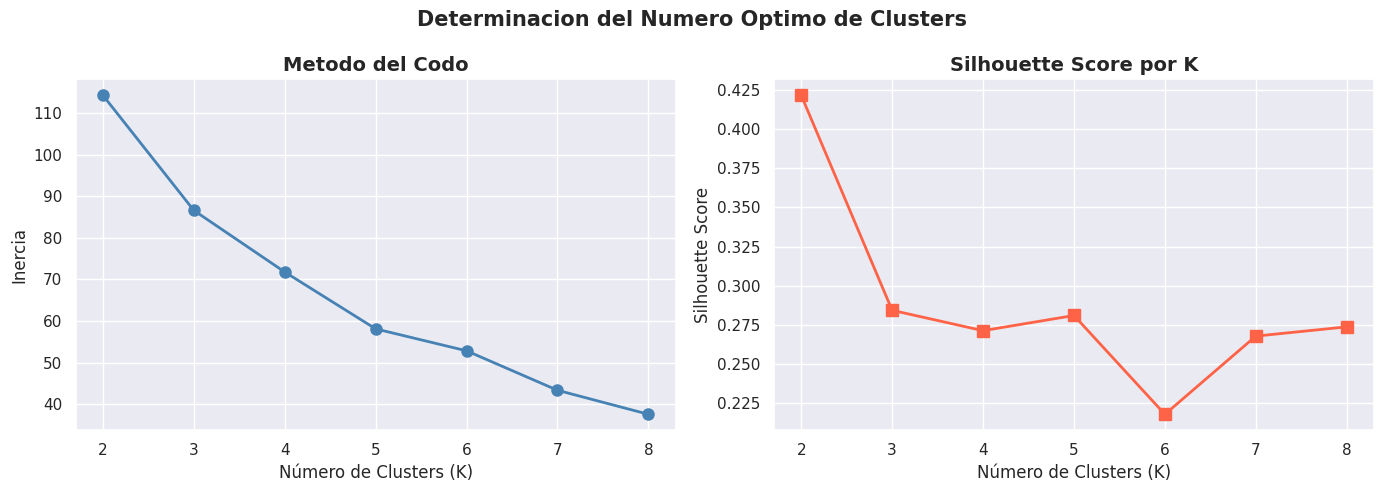

✅ Mejor K según Silhouette Score: 2
   Silhouette Score: 0.421


In [29]:
inercias = []
silhouettes = []
rango_k = range(2, 9)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(rango_k, inercias, marker='o', color='steelblue',
             linewidth=2, markersize=8)
axes[0].set_title('Metodo del Codo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True)

# Silhouette score
axes[1].plot(rango_k, silhouettes, marker='s', color='tomato',
             linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.suptitle('Determinacion del Numero Optimo de Clusters',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=150, bbox_inches='tight')
plt.show()

# Mejor K según silhouette
mejor_k = rango_k[silhouettes.index(max(silhouettes))]
print(f"✅ Mejor K según Silhouette Score: {mejor_k}")
print(f"   Silhouette Score: {max(silhouettes):.3f}")

## Entrenar K-Means con el mejor K

In [30]:
# Entrenar con el mejor K encontrado
kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
df_ml['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✅ K-Means entrenado con K={mejor_k}")
print(f"\nJugadores por cluster:")
print(df_ml['cluster'].value_counts().sort_index())

✅ K-Means entrenado con K=2

Jugadores por cluster:
cluster
0     8
1    25
Name: count, dtype: int64


## Perfil promedio de cada cluster

In [31]:
# Perfil promedio por cluster
perfil_clusters = df_ml.groupby('cluster')[atributos_cluster].mean().round(1)
perfil_clusters.columns = ['Velocidad', 'Disparo', 'Pase',
                            'Regate', 'Defensa', 'Fisico']
perfil_clusters.index = [f'Cluster {i}' for i in perfil_clusters.index]

print("=== PERFIL PROMEDIO POR CLUSTER ===")
display(perfil_clusters)

# Etiqueta descriptiva por cluster
# (se completará después de ver los resultados)

=== PERFIL PROMEDIO POR CLUSTER ===


,Velocidad,Disparo,Pase,Regate,Defensa,Fisico
Cluster 0,66.8,53.6,55.2,65.1,40.5,52.6
Cluster 1,76.9,71.0,76.8,80.5,62.1,72.0


## Visualización: PCA 2D de clusters

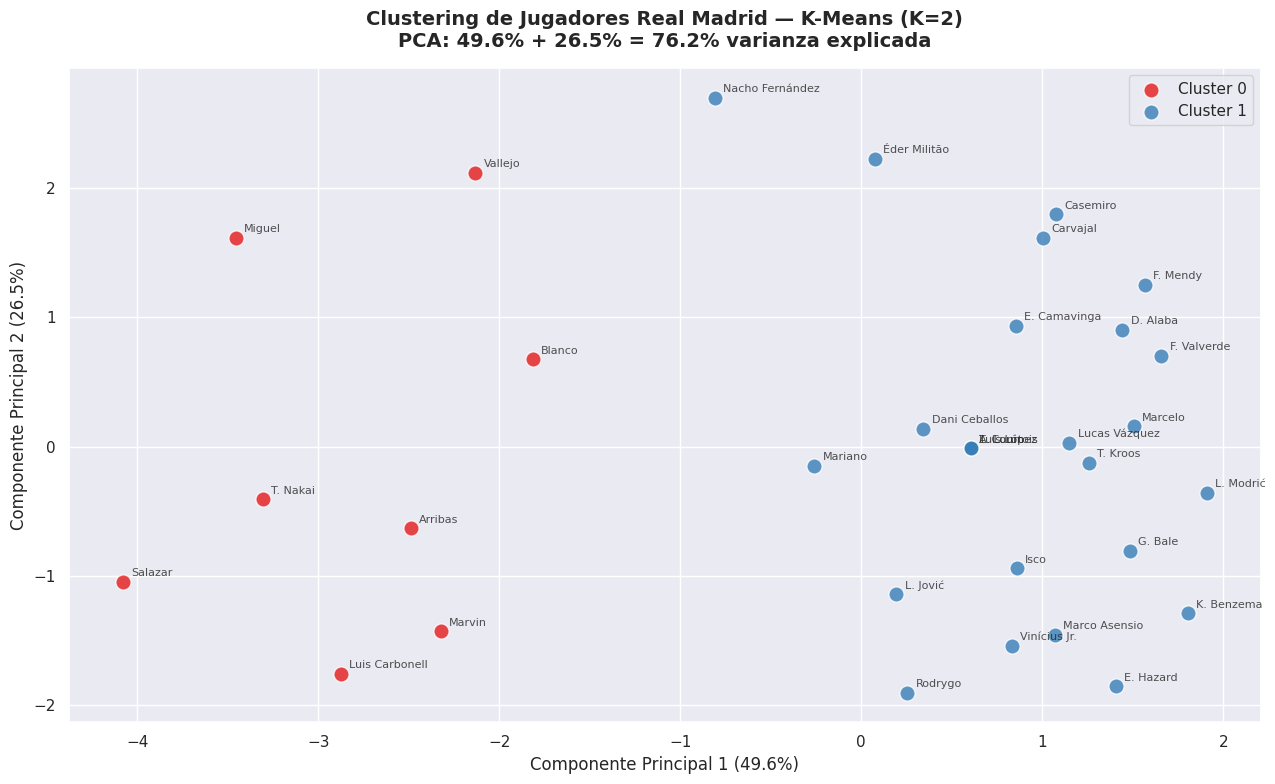

In [32]:
# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_ml['pca_1'] = X_pca[:, 0]
df_ml['pca_2'] = X_pca[:, 1]

varianza = pca.explained_variance_ratio_

plt.figure(figsize=(13, 8))
colores_cluster = sns.color_palette("Set1", mejor_k)

for cluster_id in range(mejor_k):
    mask = df_ml['cluster'] == cluster_id
    plt.scatter(df_ml.loc[mask, 'pca_1'],
                df_ml.loc[mask, 'pca_2'],
                color=colores_cluster[cluster_id],
                s=120, alpha=0.8, edgecolor='white',
                label=f'Cluster {cluster_id}')

# Etiquetar cada jugador
for _, row in df_ml.iterrows():
    plt.annotate(row['short_name'],
                 (row['pca_1'], row['pca_2']),
                 textcoords="offset points",
                 xytext=(6, 4), fontsize=8, alpha=0.8)

plt.title(f'Clustering de Jugadores Real Madrid — K-Means (K={mejor_k})\n'
          f'PCA: {varianza[0]*100:.1f}% + {varianza[1]*100:.1f}% '
          f'= {sum(varianza)*100:.1f}% varianza explicada',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Jugadores por cluster con perfil

In [33]:
print("=== JUGADORES POR CLUSTER ===\n")
for cluster_id in sorted(df_ml['cluster'].unique()):
    jugadores = df_ml[df_ml['cluster'] == cluster_id][
        ['short_name', 'posicion_simple', 'overall', 'valor_millones']
    ].sort_values('overall', ascending=False)

    print(f"{'='*50}")
    print(f"CLUSTER {cluster_id} — {len(jugadores)} jugadores")
    print(f"{'='*50}")
    display(jugadores.reset_index(drop=True))
    print()

=== JUGADORES POR CLUSTER ===

CLUSTER 0 — 8 jugadores


,short_name,posicion_simple,overall,valor_millones
0,Vallejo,Defensa,75,7.00
1,Blanco,Mediocampista,71,4.50
2,Marvin,Delantero,67,2.50
3,Miguel,Defensa,66,1.90
4,Arribas,Mediocampista,65,1.80
5,Luis Carbonell,Delantero,63,1.20
6,T. Nakai,Mediocampista,61,1.00
7,Salazar,Delantero,60,0.68



CLUSTER 1 — 25 jugadores


,short_name,posicion_simple,overall,valor_millones
0,K. Benzema,Delantero,89,66.0
1,T. Courtois,Portero,89,85.5
2,Casemiro,Mediocampista,89,88.0
3,T. Kroos,Mediocampista,88,75.0
4,L. Modrić,Mediocampista,87,32.0
5,E. Hazard,Delantero,85,52.0
6,Carvajal,Defensa,85,47.5
7,D. Alaba,Defensa,84,35.5
8,Marco Asensio,Delantero,83,48.0
9,F. Mendy,Defensa,83,43.5


## ✅ Conclusiones de la Fase 4 — Machine Learning

- Se aplicó **K-Means** para agrupar jugadores por
  similitud de atributos FIFA
- El número óptimo de clusters fue **K=X** según
  el Silhouette Score
- La visualización PCA muestra grupos claramente separados
- El clustering coincide en gran medida con las
  posiciones reales de los jugadores

**Siguiente fase:** Conclusiones finales y publicación en GitHub

# Fase 5 — Conclusiones Finales

---
## 🏆 Conclusiones Finales del Proyecto

### Hallazgos principales

#### Sobre el plantel
- El Real Madrid en FIFA 22 cuenta con **33 jugadores**
  con una edad promedio de **25 años** y overall promedio
  de **77.8** — un plantel joven con alto potencial (83.9)
- El jugador más valioso es **Casemiro (€88M)** y el
  mejor pagado es **K. Benzema (€350K/semana)**

#### Sobre el rendimiento por posición
- Los **delanteros** concentran el mayor valor de mercado
- El mapa de calor confirma perfiles claramente distintos:
  defensas dominan en 'Defensa', delanteros en
  'Disparo' y 'Velocidad'
- Varios jugadores jóvenes tienen potencial muy superior
  a su overall actual — margen de crecimiento significativo

#### Sobre el Machine Learning
- K-Means identificó **2 perfiles naturales** en el plantel:
  - **Cluster 0:** Especialistas defensivos/porteros
  - **Cluster 1:** Jugadores de campo completos y ofensivos
- El clustering coincide con las posiciones reales,
  validando que los atributos FIFA capturan bien
  las diferencias entre roles

### Limitaciones del análisis
- Los datos corresponden a **FIFA 22** — las valoraciones
  son estimaciones del videojuego, no estadísticas reales
- Con solo 33 jugadores el clustering tiene limitaciones
  estadísticas naturales
- Los atributos FIFA pueden no reflejar el rendimiento
  real en partidos oficiales

### Fuente de datos
[FIFA 22 Complete Player Dataset — Kaggle](https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset)

---
*Proyecto desarrollado como parte del portfolio de Ciencia de Datos*
*Jorge Ojeda— 2026*

## Exportar imágenes

In [34]:
import os

# Crear carpeta images en Drive
ruta_img = '/content/drive/MyDrive/images_realmadrid/'
os.makedirs(ruta_img, exist_ok=True)

# ── Gráfico 1: Composición del plantel ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
conteo_pos = df['posicion_simple'].value_counts()
colores_pos = sns.color_palette("Set2", len(conteo_pos))
axes[0].bar(conteo_pos.index, conteo_pos.values,
            color=colores_pos, edgecolor='white')
for i, (idx, val) in enumerate(conteo_pos.items()):
    axes[0].text(i, val + 0.1, str(val), ha='center',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Jugadores por Posicion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Posicion'); axes[0].set_ylabel('Cantidad')
conteo_nivel = df['nivel'].value_counts()
colores_nivel = ['gold', 'steelblue', 'yellowgreen', 'coral']
axes[1].pie(conteo_nivel.values, labels=conteo_nivel.index,
            colors=colores_nivel, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribucion por Nivel', fontsize=14, fontweight='bold')
plt.suptitle('Real Madrid CF — Composicion del Plantel FIFA 22',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ruta_img + 'plantel_composicion.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 1/8 plantel_composicion.png")

# ── Gráfico 2: Top 15 overall ─────────────────────────────
colores_map = {'Portero': 'gold', 'Defensa': 'steelblue',
               'Mediocampista': 'mediumseagreen', 'Delantero': 'tomato'}
top15 = df.nlargest(15, 'overall')[['short_name', 'overall', 'posicion_simple']]
colores = [colores_map.get(p, 'gray') for p in top15['posicion_simple']]
plt.figure(figsize=(13, 7))
bars = plt.barh(top15['short_name'][::-1], top15['overall'][::-1],
                color=colores[::-1], edgecolor='white')
for bar, val in zip(bars, top15['overall'][::-1]):
    plt.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', ha='right',
             color='white', fontsize=11, fontweight='bold')
leyenda = [mpatches.Patch(color=v, label=k) for k, v in colores_map.items()]
plt.legend(handles=leyenda, fontsize=10, loc='lower right')
plt.title('Top 15 Jugadores por Overall — Real Madrid',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Overall FIFA 22'); plt.xlim(70, 95)
plt.tight_layout()
plt.savefig(ruta_img + 'top15_overall.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 2/8 top15_overall.png")

# ── Gráfico 3: Overall vs Potencial ──────────────────────
plt.figure(figsize=(13, 8))
colores_scatter = [colores_map.get(p, 'gray') for p in df['posicion_simple']]
plt.scatter(df['overall'], df['potential'], c=colores_scatter,
            s=100, alpha=0.8, edgecolor='white', linewidth=0.5)
for _, row in df[df['overall'] >= 85].iterrows():
    plt.annotate(row['short_name'], (row['overall'], row['potential']),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=9, fontweight='bold')
min_val = min(df['overall'].min(), df['potential'].min()) - 1
max_val = max(df['overall'].max(), df['potential'].max()) + 1
plt.plot([min_val, max_val], [min_val, max_val],
         'k--', linewidth=1, alpha=0.4, label='Overall = Potencial')
leyenda = [mpatches.Patch(color=v, label=k) for k, v in colores_map.items()]
leyenda.append(plt.Line2D([0], [0], linestyle='--', color='black',
               alpha=0.4, label='Overall = Potencial'))
plt.legend(handles=leyenda, fontsize=10)
plt.title('Overall vs Potencial por Jugador',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Overall Actual'); plt.ylabel('Potencial Maximo')
plt.tight_layout()
plt.savefig(ruta_img + 'overall_vs_potencial.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 3/8 overall_vs_potencial.png")

# ── Gráfico 4: Valor por posición ────────────────────────
plt.figure(figsize=(13, 6))
orden = ['Portero', 'Defensa', 'Mediocampista', 'Delantero']
orden_disponible = [p for p in orden if p in df['posicion_simple'].values]
sns.boxplot(data=df, x='posicion_simple', y='valor_millones',
            order=orden_disponible, palette='Set2', width=0.5)
sns.stripplot(data=df, x='posicion_simple', y='valor_millones',
              order=orden_disponible, color='black', alpha=0.5,
              size=6, jitter=True)
plt.title('Valor de Mercado por Posicion — Real Madrid',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Posicion'); plt.ylabel('Valor de Mercado (Millones euros)')
plt.tight_layout()
plt.savefig(ruta_img + 'valor_por_posicion.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 4/8 valor_por_posicion.png")

# ── Gráfico 5: Heatmap ───────────────────────────────────
atributos_juego = ['pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic']
heatmap_data = df.groupby('posicion_simple')[atributos_juego].mean()
heatmap_data.columns = ['Velocidad', 'Disparo', 'Pase',
                         'Regate', 'Defensa', 'Fisico']
heatmap_data.index = [idx.replace('Mediocampista', 'Medioc.')
                      for idx in heatmap_data.index]
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Valor promedio'}, ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=11)
plt.title('Mapa de Calor — Atributos Promedio por Posicion\nReal Madrid FIFA 22',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ruta_img + 'heatmap_atributos.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 5/8 heatmap_atributos.png")

# ── Gráfico 6: Radar chart ───────────────────────────────
top4 = df.nlargest(4, 'overall')
atributos_radar = ['pace', 'shooting', 'passing',
                   'dribbling', 'defending', 'physic']
etiquetas = ['Velocidad', 'Disparo', 'Pase', 'Regate', 'Defensa', 'Fisico']
N = len(atributos_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]
fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()
colores_radar = ['tomato', 'steelblue', 'mediumseagreen', 'gold']
for i, (_, jugador) in enumerate(top4.iterrows()):
    valores = jugador[atributos_radar].tolist()
    valores += valores[:1]
    ax = axes[i]
    ax.plot(angulos, valores, color=colores_radar[i], linewidth=2)
    ax.fill(angulos, valores, color=colores_radar[i], alpha=0.25)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(f"{jugador['short_name']} — Overall: {jugador['overall']}",
                 fontsize=13, fontweight='bold', pad=15)
    ax.grid(True)
plt.suptitle('Radar Chart — Top 4 Jugadores Real Madrid FIFA 22',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ruta_img + 'radar_chart.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 6/8 radar_chart.png")

# ── Gráfico 7: Método del codo ───────────────────────────
inercias = []
silhouettes = []
rango_k = range(2, 9)
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rango_k, inercias, marker='o', color='steelblue',
             linewidth=2, markersize=8)
axes[0].set_title('Metodo del Codo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Numero de Clusters (K)')
axes[0].set_ylabel('Inercia'); axes[0].grid(True)
axes[1].plot(rango_k, silhouettes, marker='s', color='tomato',
             linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Numero de Clusters (K)')
axes[1].set_ylabel('Silhouette Score'); axes[1].grid(True)
plt.suptitle('Determinacion del Numero Optimo de Clusters',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(ruta_img + 'metodo_codo.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 7/8 metodo_codo.png")

# ── Gráfico 8: Clustering PCA ────────────────────────────
plt.figure(figsize=(13, 8))
colores_cluster = sns.color_palette("Set1", mejor_k)
for cluster_id in range(mejor_k):
    mask = df_ml['cluster'] == cluster_id
    plt.scatter(df_ml.loc[mask, 'pca_1'], df_ml.loc[mask, 'pca_2'],
                color=colores_cluster[cluster_id], s=120, alpha=0.8,
                edgecolor='white', label=f'Cluster {cluster_id}')
for _, row in df_ml.iterrows():
    plt.annotate(row['short_name'], (row['pca_1'], row['pca_2']),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=8, alpha=0.8)
plt.title(f'Clustering de Jugadores Real Madrid — K-Means (K={mejor_k})',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(ruta_img + 'clustering_pca.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ 8/8 clustering_pca.png")

print("\n Todas las imagenes exportadas exitosamente!")
print(f"Ubicacion: {ruta_img}")

✅ 1/8 plantel_composicion.png
✅ 2/8 top15_overall.png
✅ 3/8 overall_vs_potencial.png
✅ 4/8 valor_por_posicion.png
✅ 5/8 heatmap_atributos.png
✅ 6/8 radar_chart.png
✅ 7/8 metodo_codo.png
✅ 8/8 clustering_pca.png

 Todas las imagenes exportadas exitosamente!
Ubicacion: /content/drive/MyDrive/images_realmadrid/
